# Predicción Oceanográfica con RNN (LSTM)



# 1. Importación de librerías

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, TimeDistributed, RepeatVector
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)


# 2. Importación de la fuente de datos (Open-Meteo)



## 2.1 Zona de estudio y periodo de datos

In [2]:
ZONA_NOMBRE = "Golfo de Nicoya, Costa Rica"   # Cambia esto por tu zona de interés
LATITUDE = 9.97
LONGITUDE = -84.90

HIST_DAYS = 730       # ~2 años de historia para entrenar (la Historical Forecast API cubre desde ~2021)
TEST_DAYS = 30         # tamaño del conjunto de test, según la métrica pedida
INPUT_HOURS = 72       # horas de contexto que ve el modelo (3 días)
OUTPUT_HOURS = 72      # horas hacia adelante que predice el modelo

TIMEZONE = "auto"


In [3]:
today = datetime.now(timezone.utc).date()
hist_start = today - timedelta(days=HIST_DAYS + TEST_DAYS)
hist_end = today - timedelta(days=1)

print(f"Zona: {ZONA_NOMBRE} ({LATITUDE}, {LONGITUDE})")
print(f"Rango a descargar: {hist_start} -> {hist_end}")


Zona: Golfo de Nicoya, Costa Rica (9.97, -84.9)
Rango a descargar: 2024-06-11 -> 2026-07-10


## 2.2 Descarga de oleaje, marea y SST (Marine API)

In [4]:
MARINE_URL = "https://marine-api.open-meteo.com/v1/marine"

MARINE_VARS = [
    "wave_height",
    "wave_direction",
    "wave_period",
    "sea_surface_temperature",
    "sea_level_height_msl",   # esta es la marea
]


In [5]:
def fetch_marine_data(lat, lon, start_date, end_date, timezone_="auto"):
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join(MARINE_VARS),
        "start_date": str(start_date),
        "end_date": str(end_date),
        "timezone": timezone_,
    }
    r = requests.get(MARINE_URL, params=params, timeout=60)
    if not r.ok:
        raise RuntimeError(f"Error {r.status_code} en Marine API: {r.text}")
    data = r.json()
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")
    return df


In [6]:
df_marine = fetch_marine_data(LATITUDE, LONGITUDE, hist_start, hist_end, TIMEZONE)
df_marine.shape

(18240, 5)

In [7]:
df_marine.head()

,wave_height,wave_direction,wave_period,sea_surface_temperature,sea_level_height_msl
time,,,,,
2024-06-11 00:00:00,0.18,176,7.30,30.5,-0.78
2024-06-11 01:00:00,0.18,176,7.15,30.5,-0.47
2024-06-11 02:00:00,0.20,175,7.00,30.5,0.01
2024-06-11 03:00:00,0.20,175,6.85,30.5,0.50
2024-06-11 04:00:00,0.20,175,6.75,30.5,0.92


## 2.3 Descarga de viento y presión (Historical Forecast API)

⚠️ Usamos `historical-forecast-api.open-meteo.com`, **no** `api.open-meteo.com/v1/forecast` — este último es solo para pronóstico en vivo y no admite pedir varios meses/años de historia con `start_date`/`end_date` (devuelve una respuesta vacía).

In [8]:
WEATHER_URL = "https://historical-forecast-api.open-meteo.com/v1/forecast"

WEATHER_VARS = [
    "wind_speed_10m",
    "wind_direction_10m",
    "surface_pressure",
]


In [9]:
def fetch_weather_data(lat, lon, start_date, end_date, timezone_="auto"):
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join(WEATHER_VARS),
        "start_date": str(start_date),
        "end_date": str(end_date),
        "timezone": timezone_,
    }
    r = requests.get(WEATHER_URL, params=params, timeout=60)
    if not r.ok:
        raise RuntimeError(f"Error {r.status_code} en Historical Forecast API: {r.text}")
    data = r.json()
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")
    return df


In [10]:
df_weather = fetch_weather_data(LATITUDE, LONGITUDE, hist_start, hist_end, TIMEZONE)
df_weather.shape

(18240, 3)

In [11]:
df_weather.head()

,wind_speed_10m,wind_direction_10m,surface_pressure
time,,,
2024-06-11 00:00:00,11.5,148,1010.9
2024-06-11 01:00:00,10.3,144,1010.6
2024-06-11 02:00:00,10.5,131,1010.0
2024-06-11 03:00:00,9.1,108,1009.7
2024-06-11 04:00:00,8.6,123,1009.7


# 3. Preprocesado

## 3.1 Unimos las dos fuentes

In [12]:
df = df_marine.join(df_weather, how="inner")
df.shape

(18240, 8)

In [13]:
df.head()

,wave_height,wave_direction,wave_period,sea_surface_temperature,sea_level_height_msl,wind_speed_10m,wind_direction_10m,surface_pressure
time,,,,,,,,
2024-06-11 00:00:00,0.18,176,7.30,30.5,-0.78,11.5,148,1010.9
2024-06-11 01:00:00,0.18,176,7.15,30.5,-0.47,10.3,144,1010.6
2024-06-11 02:00:00,0.20,175,7.00,30.5,0.01,10.5,131,1010.0
2024-06-11 03:00:00,0.20,175,6.85,30.5,0.50,9.1,108,1009.7
2024-06-11 04:00:00,0.20,175,6.75,30.5,0.92,8.6,123,1009.7


## 3.2 Variables derivadas



**Direcciones (oleaje y viento):** vienen en grados (0-360°). Si se las diéramos así al modelo, 359° y 1° le parecerían valores lejanos cuando en realidad son casi el mismo punto. Por eso las convertimos a seno/coseno (codificación circular).

In [14]:
df["wave_dir_sin"] = np.sin(np.deg2rad(df["wave_direction"]))
df["wave_dir_cos"] = np.cos(np.deg2rad(df["wave_direction"]))
df["wind_dir_sin"] = np.sin(np.deg2rad(df["wind_direction_10m"]))
df["wind_dir_cos"] = np.cos(np.deg2rad(df["wind_direction_10m"]))
df = df.drop(columns=["wave_direction", "wind_direction_10m"])


**Fase lunar:** ninguna API de Open-Meteo la entrega, así que la calculamos con una fórmula astronómica (ciclo sinódico de ~29.53 días desde una luna nueva de referencia conocida).

In [15]:
SYNODIC_MONTH = 29.530588853  # días
REFERENCE_NEW_MOON = datetime(2000, 1, 6, 18, 14, tzinfo=timezone.utc)

def moon_phase_fraction(dt):
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    days_since = (dt - REFERENCE_NEW_MOON).total_seconds() / 86400.0
    return (days_since % SYNODIC_MONTH) / SYNODIC_MONTH


In [16]:
phase = df.index.to_series().apply(moon_phase_fraction)
df["moon_phase_sin"] = np.sin(2 * np.pi * phase)
df["moon_phase_cos"] = np.cos(2 * np.pi * phase)


**Hora del día y día del año:** ciclos térmicos/atmosféricos (temperatura, presión, brisas costeras siguen el día solar de 24h).

In [17]:
hour = df.index.hour + df.index.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

doy = df.index.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)


**Periodicidad de marea

In [18]:
hours_elapsed = (df.index - df.index[0]).total_seconds() / 3600.0
df["tide_semidiurnal_sin"] = np.sin(2 * np.pi * hours_elapsed / 12.4206)
df["tide_semidiurnal_cos"] = np.cos(2 * np.pi * hours_elapsed / 12.4206)
df["tide_lunarday_sin"] = np.sin(2 * np.pi * hours_elapsed / 24.8412)
df["tide_lunarday_cos"] = np.cos(2 * np.pi * hours_elapsed / 24.8412)


In [19]:
df.head()

,wave_height,wave_period,sea_surface_temperature,sea_level_height_msl,wind_speed_10m,surface_pressure,wave_dir_sin,wave_dir_cos,wind_dir_sin,wind_dir_cos,moon_phase_sin,moon_phase_cos,hour_sin,hour_cos,doy_sin,doy_cos,tide_semidiurnal_sin,tide_semidiurnal_cos,tide_lunarday_sin,tide_lunarday_cos
time,,,,,,,,,,,,,,,,,,,,
2024-06-11 00:00:00,0.18,7.30,30.5,-0.78,11.5,1010.9,0.069756,-0.997564,0.529919,-0.848048,0.752332,0.658784,0.000000,1.000000,0.331221,-0.943553,0.000000,1.000000,0.000000,1.000000
2024-06-11 01:00:00,0.18,7.15,30.5,-0.47,10.3,1010.6,0.069756,-0.997564,0.587785,-0.809017,0.758143,0.652089,0.258819,0.965926,0.331221,-0.943553,0.484567,0.874754,0.250246,0.968182
2024-06-11 02:00:00,0.20,7.00,30.5,0.01,10.5,1010.0,0.087156,-0.996195,0.754710,-0.656059,0.763894,0.645342,0.500000,0.866025,0.331221,-0.943553,0.847754,0.530390,0.484567,0.874754
2024-06-11 03:00:00,0.20,6.85,30.5,0.50,9.1,1009.7,0.087156,-0.996195,0.951057,-0.309017,0.769585,0.638544,0.707107,0.707107,0.331221,-0.943553,0.998586,0.053167,0.688053,0.725661
2024-06-11 04:00:00,0.20,6.75,30.5,0.92,8.6,1009.7,0.087156,-0.996195,0.838671,-0.544639,0.775216,0.631697,0.866025,0.500000,0.331221,-0.943553,0.899280,-0.437374,0.847754,0.530390


## 3.3 Valores faltantes

Open-Meteo a veces tiene huecos horarios puntuales. Los rellenamos por interpolación temporal.

In [20]:
df.isna().sum()

wave_height                  0
wave_period                  0
sea_surface_temperature    312
sea_level_height_msl       432
wind_speed_10m               0
surface_pressure             0
wave_dir_sin                 0
wave_dir_cos                 0
wind_dir_sin                 0
wind_dir_cos                 0
moon_phase_sin               0
moon_phase_cos               0
hour_sin                     0
hour_cos                     0
doy_sin                      0
doy_cos                      0
tide_semidiurnal_sin         0
tide_semidiurnal_cos         0
tide_lunarday_sin            0
tide_lunarday_cos            0
dtype: int64

In [21]:
df = df.interpolate(method="time").ffill().bfill()
df.isna().sum()

wave_height                0
wave_period                0
sea_surface_temperature    0
sea_level_height_msl       0
wind_speed_10m             0
surface_pressure           0
wave_dir_sin               0
wave_dir_cos               0
wind_dir_sin               0
wind_dir_cos               0
moon_phase_sin             0
moon_phase_cos             0
hour_sin                   0
hour_cos                   0
doy_sin                    0
doy_cos                    0
tide_semidiurnal_sin       0
tide_semidiurnal_cos       0
tide_lunarday_sin          0
tide_lunarday_cos          0
dtype: int64

## 3.4 Visualización de las series

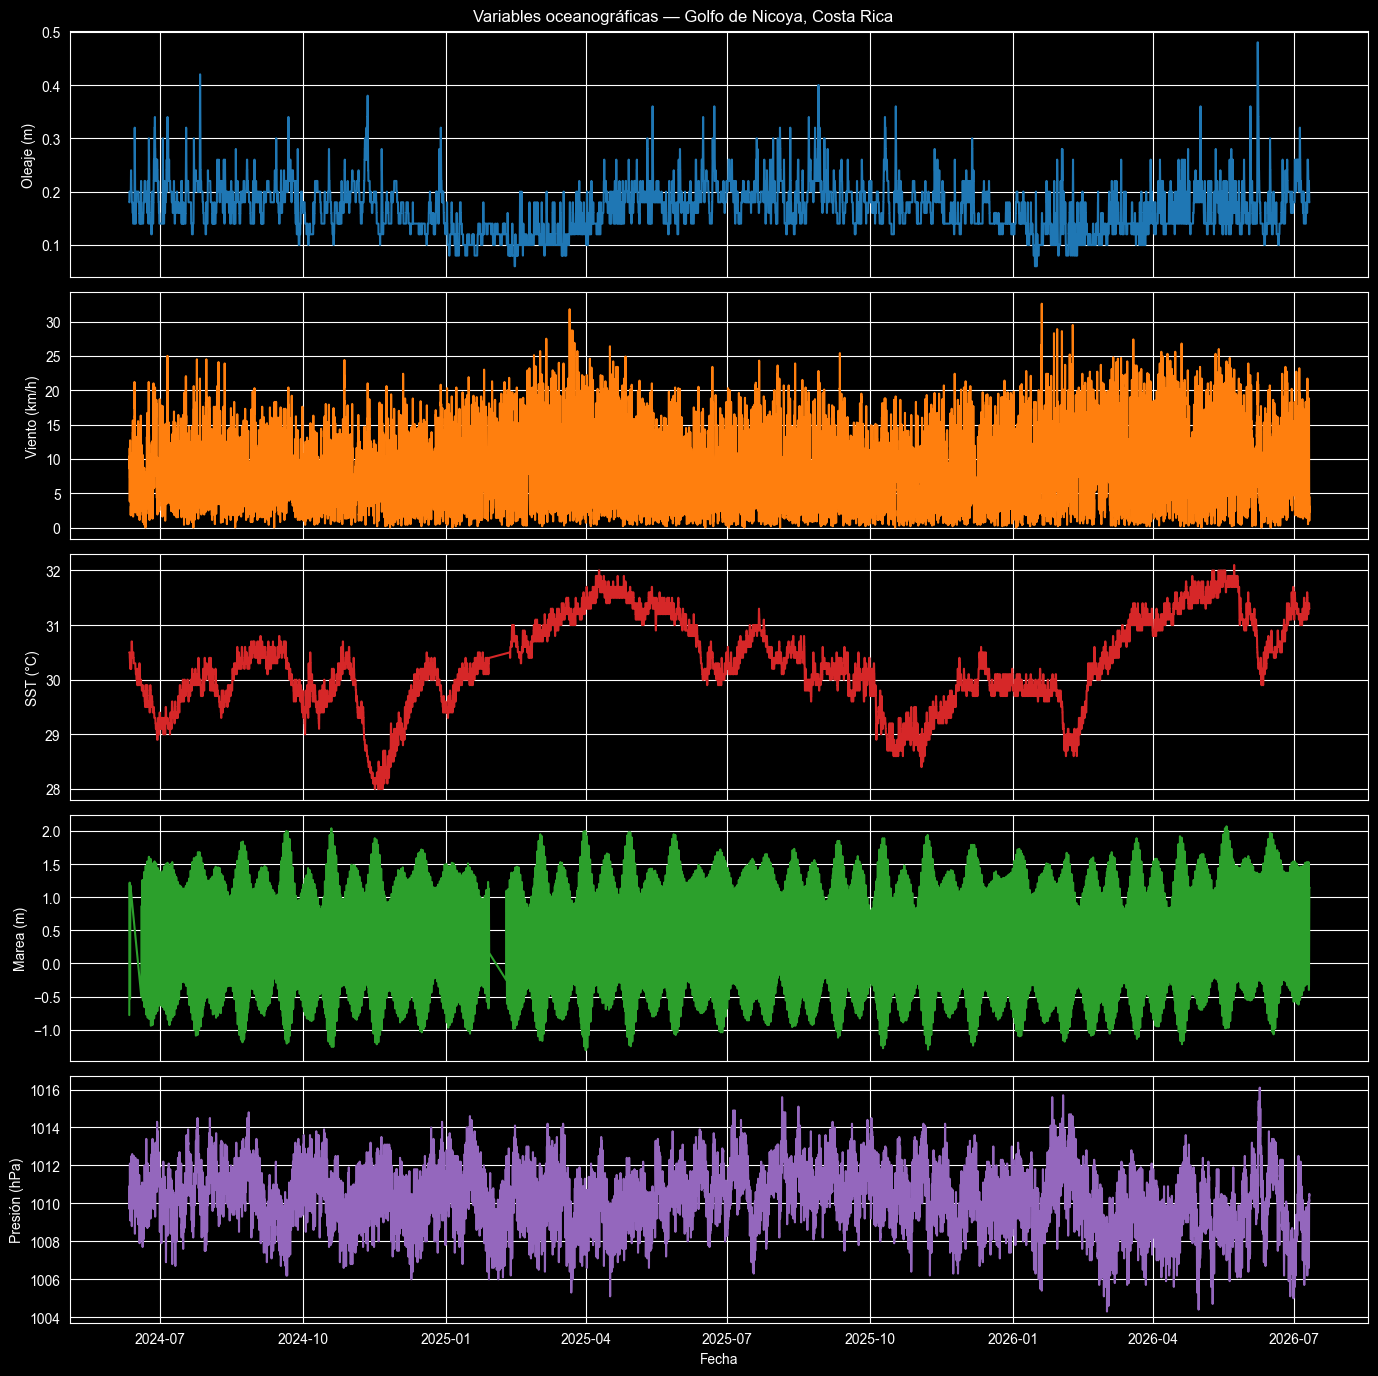

In [22]:
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
axes[0].plot(df.index, df["wave_height"], color="tab:blue");            axes[0].set_ylabel("Oleaje (m)")
axes[1].plot(df.index, df["wind_speed_10m"], color="tab:orange");       axes[1].set_ylabel("Viento (km/h)")
axes[2].plot(df.index, df["sea_surface_temperature"], color="tab:red"); axes[2].set_ylabel("SST (°C)")
axes[3].plot(df.index, df["sea_level_height_msl"], color="tab:green");  axes[3].set_ylabel("Marea (m)")
axes[4].plot(df.index, df["surface_pressure"], color="tab:purple");     axes[4].set_ylabel("Presión (hPa)")
axes[4].set_xlabel("Fecha")
fig.suptitle(f"Variables oceanográficas — {ZONA_NOMBRE}")
plt.tight_layout()
plt.show()


## 3.5 Seleccionamos las columnas finales

`TARGET_COLS`: lo que el modelo va a predecir. `FEATURE_COLS`: todo lo que el modelo ve como entrada (incluye a los targets más las variables auxiliares que acabamos de crear).

In [23]:
TARGET_COLS = [
    "wave_height",
    "wind_speed_10m",
    "sea_surface_temperature",
    "sea_level_height_msl",
    "surface_pressure",
]

FEATURE_COLS = [
    "wave_height", "wave_period", "sea_surface_temperature", "sea_level_height_msl",
    "wind_speed_10m", "surface_pressure",
    "wave_dir_sin", "wave_dir_cos", "wind_dir_sin", "wind_dir_cos",
    "moon_phase_sin", "moon_phase_cos",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "tide_semidiurnal_sin", "tide_semidiurnal_cos", "tide_lunarday_sin", "tide_lunarday_cos",
]

data = df[FEATURE_COLS].copy()
target_idx = [FEATURE_COLS.index(c) for c in TARGET_COLS]  # dónde están los targets dentro de FEATURE_COLS

print(f"{len(FEATURE_COLS)} columnas de entrada, {len(TARGET_COLS)} variables objetivo")


20 columnas de entrada, 5 variables objetivo


# 4. Train / Test Split



In [24]:
len(data)

18240

In [25]:
test_hours = TEST_DAYS * 24
test_ind = len(data) - test_hours
test_ind

17520

In [26]:
train = data.iloc[:test_ind]
test = data.iloc[test_ind - INPUT_HOURS:]   # incluimos INPUT_HOURS de contexto previo, para poder predecir desde el primer punto del test


In [27]:
train.shape

(17520, 20)

In [28]:
test.shape

(792, 20)

# 5. Escalado



In [29]:
scaler = MinMaxScaler()
scaler.fit(train.values)


,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [30]:
scaled_train = scaler.transform(train.values)
scaled_test = scaler.transform(test.values)


In [31]:
scaled_train.min(), scaled_train.max()

(np.float64(0.0), np.float64(1.0))

# 6. Creación de secuencias



In [32]:
def create_sequences(arr, target_idx, input_hours, output_hours):
    X, y = [], []
    n = len(arr)
    for i in range(n - input_hours - output_hours + 1):
        X.append(arr[i : i + input_hours, :])
        y.append(arr[i + input_hours : i + input_hours + output_hours, target_idx])
    return np.array(X), np.array(y)


In [33]:
X_train, y_train = create_sequences(scaled_train, target_idx, INPUT_HOURS, OUTPUT_HOURS)
X_test, y_test = create_sequences(scaled_test, target_idx, INPUT_HOURS, OUTPUT_HOURS)


In [34]:
X_train.shape, y_train.shape

((17377, 72, 20), (17377, 72, 5))

In [35]:
X_test.shape, y_test.shape

((649, 72, 20), (649, 72, 5))

 veamos qué contiene el primer batch, para entender qué le estamos dando al modelo:

In [36]:
print(f"X_train[0] tiene forma {X_train[0].shape}: {INPUT_HOURS} horas pasadas x {len(FEATURE_COLS)} variables")
print(f"y_train[0] tiene forma {y_train[0].shape}: {OUTPUT_HOURS} horas futuras x {len(TARGET_COLS)} variables objetivo")


X_train[0] tiene forma (72, 20): 72 horas pasadas x 20 variables
y_train[0] tiene forma (72, 5): 72 horas futuras x 5 variables objetivo


# 7. Creación del modelo



- **Encoder** (2 capas LSTM): "lee" las 72h de entrada y las resume en un estado.
- **Decoder**: repite ese estado 72 veces (`RepeatVector`) y una LSTM genera la salida hora por hora, en vez de escupir las 72×5=360 salidas de un solo golpe con una única `Dense` (probamos eso primero y el modelo colapsaba a predecir casi una constante).
- **Una cabeza de salida por variable** (`TimeDistributed(Dense)` independiente para cada una de las 5): evita que oleaje/viento (ruidosos) le "quiten protagonismo" a SST/presión (suaves) dentro de una sola capa compartida.

In [37]:
n_features = X_train.shape[2]
n_targets = len(TARGET_COLS)
n_features, n_targets

(20, 5)

In [38]:
inputs = Input(shape=(INPUT_HOURS, n_features))

# Encoder: comprime las 72h de entrada
x = LSTM(128, return_sequences=True, dropout=0.15)(inputs)
encoder_out = LSTM(64, return_sequences=False, dropout=0.15)(x)

# Decoder: genera la secuencia de salida paso a paso
x = RepeatVector(OUTPUT_HOURS)(encoder_out)
decoder_seq = LSTM(64, return_sequences=True, dropout=0.15)(x)


In [39]:
# Una cabeza de salida independiente por variable objetivo
outputs_list = []
for name in TARGET_COLS:
    h = TimeDistributed(Dense(16, activation="relu"), name=f"head_{name}_dense")(decoder_seq)
    out = TimeDistributed(Dense(1, activation="linear"), name=name)(h)
    outputs_list.append(out)


In [40]:
model = Model(inputs, outputs_list)   # lista de salidas, no diccionario (más estable en Keras)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss=["mse"] * n_targets,
    metrics=["mae"] * n_targets,
)


In [41]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 72, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 72, 128)   │     76,288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 72, 64)    │          0 │ lstm_1[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 72, 64)    │     33,024 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_wave_height_d… │ (None, 72, 16)    │      1,040 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_wind_speed_10… │ (None, 72, 16)    │      1,040 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_sea_surface_t… │ (None, 72, 16)    │      1,040 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_sea_level_hei… │ (None, 72, 16)    │      1,040 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_surface_press… │ (None, 72, 16)    │      1,040 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wave_height         │ (None, 72, 1)     │         17 │ head_wave_height… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_speed_10m      │ (None, 72, 1)     │         17 │ head_wind_speed_… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sea_surface_temper… │ (None, 72, 1)     │         17 │ head_sea_surface… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sea_level_height_m… │ (None, 72, 1)     │         17 │ head_sea_level_h… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surface_pressure    │ (None, 72, 1)     │         17 │ head_surface_pre… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,005 (640.64 KB)

 Trainable params: 164,005 (640.64 KB)

 Non-trainable params: 0 (0.00 B)

# 8. Entrenamiento del modelo

 usamos `EarlyStopping` para no sobreentrenar. Como el modelo tiene 5 salidas (una lista), hay que convertir `y_train`/`y_test` al mismo formato de lista antes de entrenar.

In [42]:
def to_list_targets(y_array, target_names):
    return [y_array[:, :, i:i+1] for i in range(len(target_names))]

y_train_list = to_list_targets(y_train, TARGET_COLS)
y_test_list = to_list_targets(y_test, TARGET_COLS)


In [43]:
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)


In [44]:
history = model.fit(
    X_train, y_train_list,
    validation_data=(X_test, y_test_list),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 1/100
544/544 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - loss: 0.1238 - sea_level_height_msl_loss: 0.0457 - sea_level_height_msl_mae: 0.1836 - sea_surface_temperature_loss: 0.0194 - sea_surface_temperature_mae: 0.1024 - surface_pressure_loss: 0.0218 - surface_pressure_mae: 0.1144 - wave_height_loss: 0.0105 - wave_height_mae: 0.0782 - wind_speed_10m_loss: 0.0264 - wind_speed_10m_mae: 0.1323 - val_loss: 0.1272 - val_sea_level_height_msl_loss: 0.0466 - val_sea_level_height_msl_mae: 0.1883 - val_sea_surface_temperature_loss: 0.0102 - val_sea_surface_temperature_mae: 0.0881 - val_surface_pressure_loss: 0.0346 - val_surface_pressure_mae: 0.1571 - val_wave_height_loss: 0.0099 - val_wave_height_mae: 0.0812 - val_wind_speed_10m_loss: 0.0260 - val_wind_speed_10m_mae: 0.1300 - learning_rate: 8.0000e-04
Epoch 2/100
544/544 ━━━━━━━━━━━━━━━━━━━━ 47s 86ms/step - loss: 0.1032 - sea_level_height_msl_loss: 0.0435 - sea_level_height_msl_mae: 0.1805 - sea_surface_temperature_loss: 0.0085 - sea_surface_tem

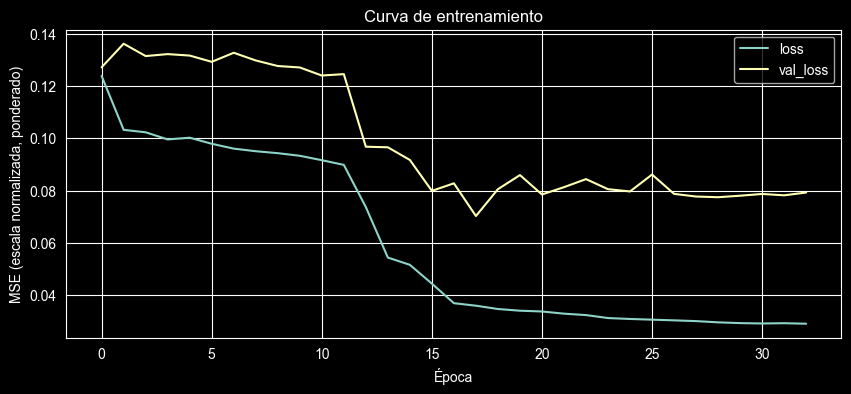

In [45]:
losses = pd.DataFrame(history.history)
losses[["loss", "val_loss"]].plot(figsize=(10, 4), title="Curva de entrenamiento")
plt.xlabel("Época")
plt.ylabel("MSE (escala normalizada, ponderado)")
plt.show()


# 9. Evaluación del modelo

## 9.1 Predicción sobre el conjunto de test

In [46]:
def inverse_transform_targets(scaled_targets, scaler, target_idx, n_features):
    """(n_samples, output_hours, n_targets) en escala [0,1] -> unidades reales."""
    n_samples, out_h, n_t = scaled_targets.shape
    flat = scaled_targets.reshape(-1, n_t)
    dummy = np.zeros((flat.shape[0], n_features))
    dummy[:, target_idx] = flat
    inv = scaler.inverse_transform(dummy)[:, target_idx]
    return inv.reshape(n_samples, out_h, n_t)


In [47]:
y_pred_scaled_list = model.predict(X_test)
y_pred_scaled = np.concatenate(y_pred_scaled_list, axis=-1)  # mismo orden que TARGET_COLS


21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step


In [48]:
y_pred = inverse_transform_targets(y_pred_scaled, scaler, target_idx, n_features)
y_true = inverse_transform_targets(y_test, scaler, target_idx, n_features)


## 9.2 Métricas: RMSE y MAE



In [49]:
rows = []
for i, col in enumerate(TARGET_COLS):
    yt = y_true[:, :, i].ravel()
    yp = y_pred[:, :, i].ravel()
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    rows.append({"variable": col, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

metrics_df = pd.DataFrame(rows)
metrics_df

,variable,RMSE,MAE
0,wave_height,0.0436,0.0359
1,wind_speed_10m,3.9638,3.1637
2,sea_surface_temperature,0.5549,0.5323
3,sea_level_height_msl,0.2297,0.1811
4,surface_pressure,1.7393,1.4620


## 9.3 Visualización: predicción vs. realidad, para un punto del test

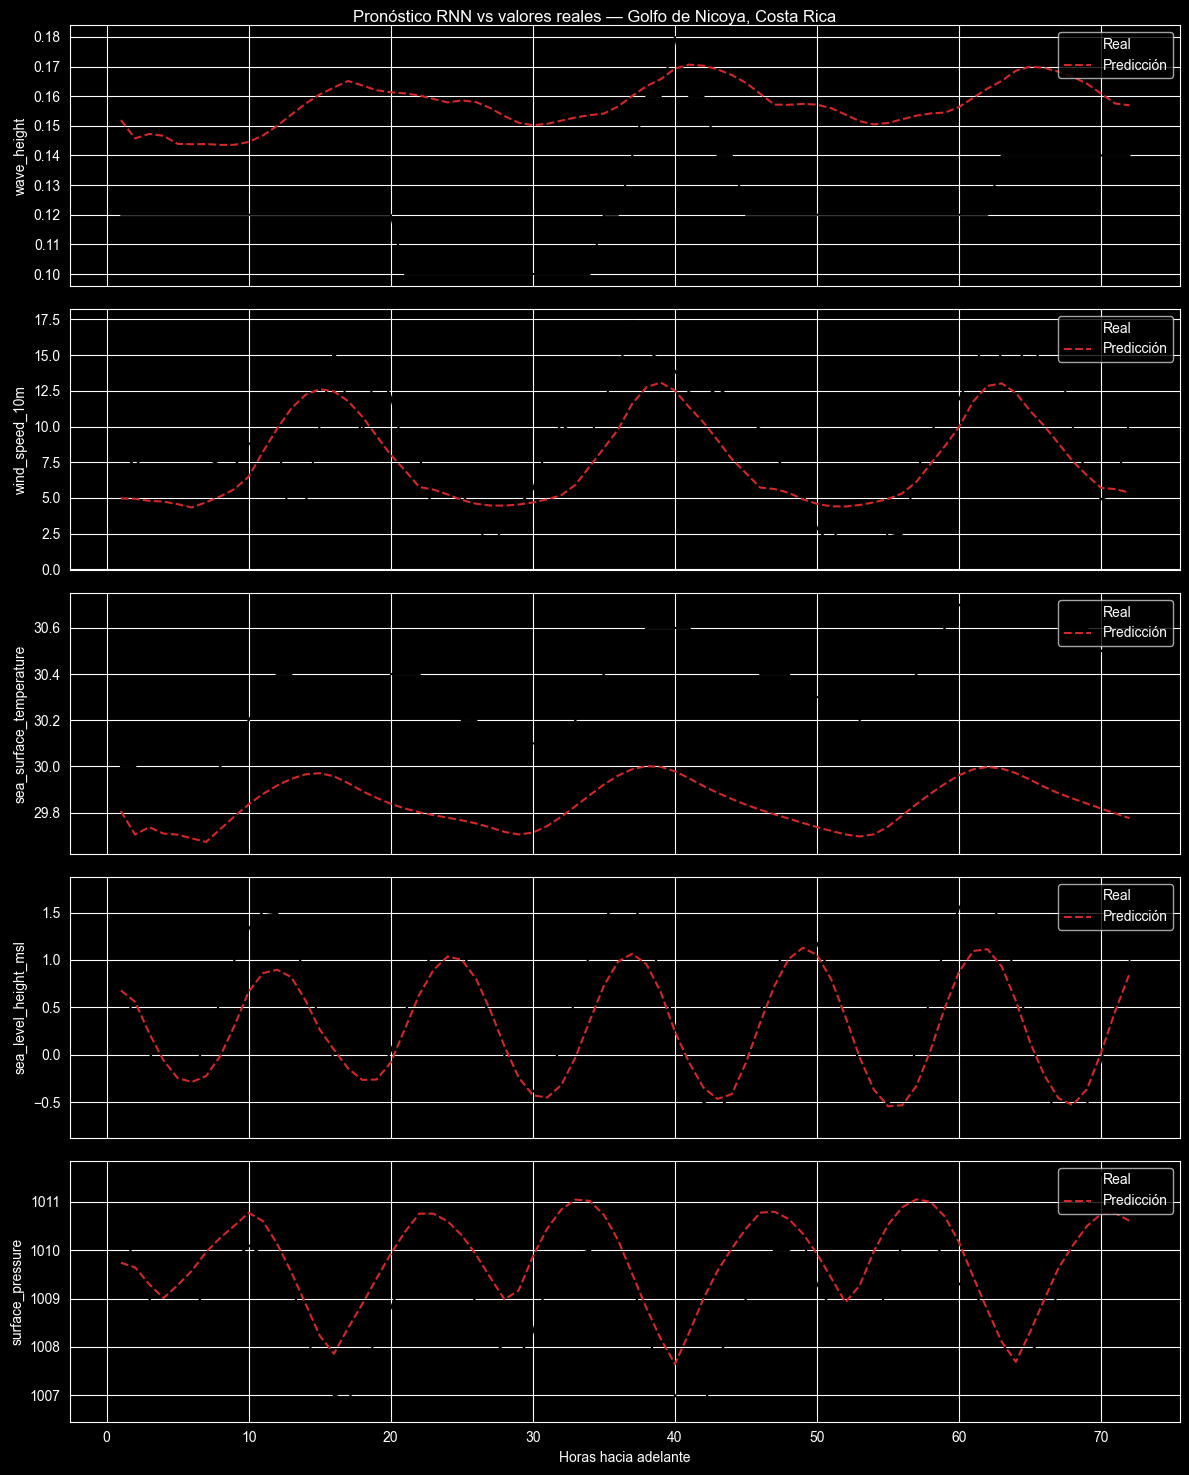

In [50]:
sample_idx = 0  # cambia este índice para ver otros puntos de partida del test

fig, axes = plt.subplots(len(TARGET_COLS), 1, figsize=(12, 3 * len(TARGET_COLS)), sharex=True)
horas = np.arange(1, OUTPUT_HOURS + 1)

for i, col in enumerate(TARGET_COLS):
    axes[i].plot(horas, y_true[sample_idx, :, i], label="Real", color="black")
    axes[i].plot(horas, y_pred[sample_idx, :, i], label="Predicción", color="tab:red", linestyle="--")
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper right")

axes[-1].set_xlabel("Horas hacia adelante")
fig.suptitle(f"Pronóstico RNN vs valores reales — {ZONA_NOMBRE}")
plt.tight_layout()
plt.show()


# 10. Predicción de nuevos datos (forecast real)

 ("Predicción de nuevos datos"): una vez que confiamos en el modelo, lo re-entrenamos con **todos** los datos disponibles (train + test juntos) y lo usamos para predecir de verdad hacia adelante, más allá del último dato que tenemos.

In [51]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(data.values)


In [52]:
X_full, y_full = create_sequences(scaled_full_data, target_idx, INPUT_HOURS, OUTPUT_HOURS)
y_full_list = to_list_targets(y_full, TARGET_COLS)
X_full.shape

(18097, 72, 20)

Reconstruimos el modelo desde cero (mismos hiperparámetros) y lo entrenamos con todo el histórico, usando el mismo número de épocas que le tomó converger antes (sin `EarlyStopping`, porque ya no hay un conjunto de validación separado):

In [53]:
best_epoch_count = len(history.history["loss"])
print(f"Entrenaremos {best_epoch_count} épocas (las que le tomó converger en el paso anterior)")


Entrenaremos 33 épocas (las que le tomó converger en el paso anterior)


In [54]:
inputs_f = Input(shape=(INPUT_HOURS, n_features))
xf = LSTM(128, return_sequences=True, dropout=0.15)(inputs_f)
encoder_out_f = LSTM(64, return_sequences=False, dropout=0.15)(xf)
xf = RepeatVector(OUTPUT_HOURS)(encoder_out_f)
decoder_seq_f = LSTM(64, return_sequences=True, dropout=0.15)(xf)

outputs_list_f = []
for name in TARGET_COLS:
    h = TimeDistributed(Dense(16, activation="relu"), name=f"final_head_{name}_dense")(decoder_seq_f)
    out = TimeDistributed(Dense(1, activation="linear"), name=f"final_{name}")(h)
    outputs_list_f.append(out)

final_model = Model(inputs_f, outputs_list_f)
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss=["mse"] * n_targets,
    metrics=["mae"] * n_targets,
)


In [55]:
final_model.fit(X_full, y_full_list, epochs=best_epoch_count, batch_size=32, verbose=1)


Epoch 1/33
566/566 ━━━━━━━━━━━━━━━━━━━━ 71s 84ms/step - final_sea_level_height_msl_loss: 0.0463 - final_sea_level_height_msl_mae: 0.1843 - final_sea_surface_temperature_loss: 0.0183 - final_sea_surface_temperature_mae: 0.0989 - final_surface_pressure_loss: 0.0238 - final_surface_pressure_mae: 0.1180 - final_wave_height_loss: 0.0108 - final_wave_height_mae: 0.0797 - final_wind_speed_10m_loss: 0.0268 - final_wind_speed_10m_mae: 0.1330 - loss: 0.1259
Epoch 2/33
566/566 ━━━━━━━━━━━━━━━━━━━━ 62s 110ms/step - final_sea_level_height_msl_loss: 0.0435 - final_sea_level_height_msl_mae: 0.1807 - final_sea_surface_temperature_loss: 0.0083 - final_sea_surface_temperature_mae: 0.0651 - final_surface_pressure_loss: 0.0173 - final_surface_pressure_mae: 0.1058 - final_wave_height_loss: 0.0091 - final_wave_height_mae: 0.0728 - final_wind_speed_10m_loss: 0.0254 - final_wind_speed_10m_mae: 0.1304 - loss: 0.1037
Epoch 3/33
566/566 ━━━━━━━━━━━━━━━━━━━━ 79s 139ms/step - final_sea_level_height_msl_loss: 0.043

Tomamos las últimas `INPUT_HOURS` horas disponibles como punto de partida y generamos el pronóstico real hacia adelante:

In [56]:
ultimo_batch = scaled_full_data[-INPUT_HOURS:]
ultimo_batch = ultimo_batch.reshape((1, INPUT_HOURS, n_features))
ultimo_batch.shape

(1, 72, 20)

In [57]:
forecast_scaled_list = final_model.predict(ultimo_batch)
forecast_scaled = np.concatenate(forecast_scaled_list, axis=-1)  # (1, OUTPUT_HOURS, n_targets)
forecast_real = inverse_transform_targets(forecast_scaled, full_scaler, target_idx, n_features)[0]  # (OUTPUT_HOURS, n_targets)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [58]:
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=OUTPUT_HOURS, freq="h")
forecast_df = pd.DataFrame(forecast_real, index=forecast_index, columns=TARGET_COLS)
forecast_df.head()

,wave_height,wind_speed_10m,sea_surface_temperature,sea_level_height_msl,surface_pressure
2026-07-11 00:00:00,0.161513,6.069014,30.664373,0.805017,1010.427515
2026-07-11 01:00:00,0.163389,5.492611,30.626299,0.783168,1010.423493
2026-07-11 02:00:00,0.161322,5.170863,30.641593,0.481425,1010.498462
2026-07-11 03:00:00,0.158215,5.129734,30.583242,-0.057110,1010.639062
2026-07-11 04:00:00,0.158117,5.300110,30.640174,-0.395035,1010.993794


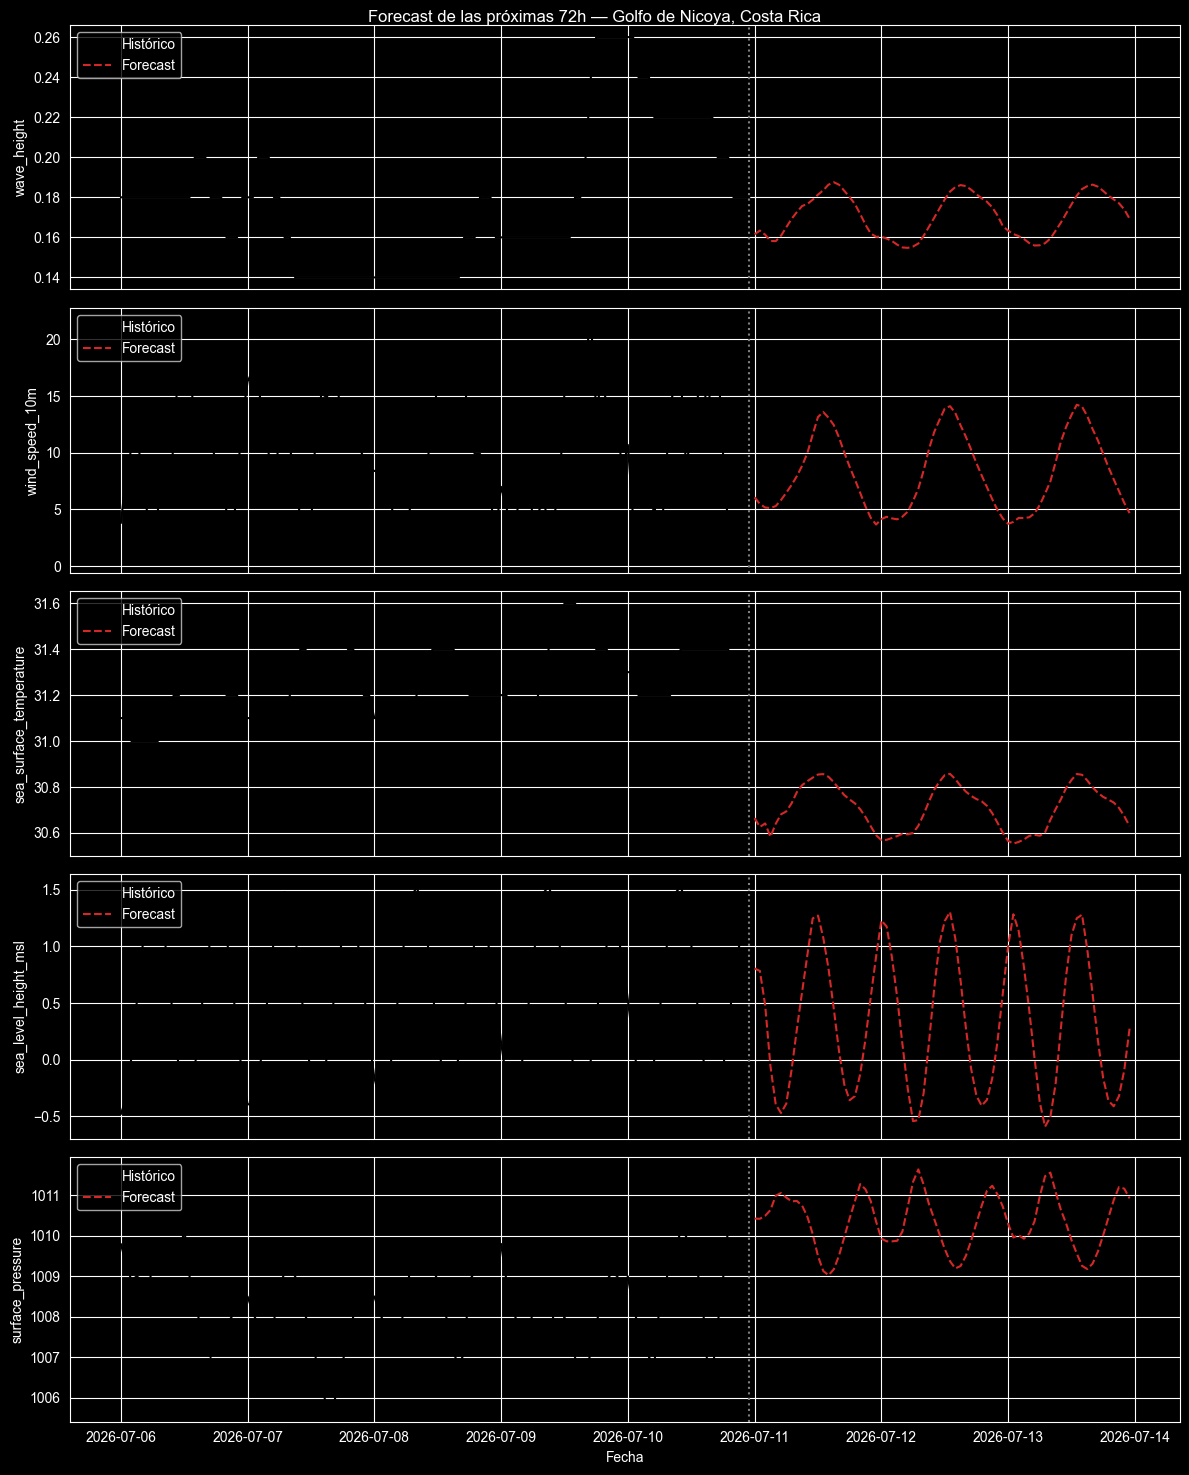

In [59]:
fig, axes = plt.subplots(len(TARGET_COLS), 1, figsize=(12, 3 * len(TARGET_COLS)), sharex=True)
dias_contexto = 5  # cuántos días de historia mostrar antes del forecast, para dar contexto

for i, col in enumerate(TARGET_COLS):
    historico_reciente = df[col].iloc[-24 * dias_contexto:]
    axes[i].plot(historico_reciente.index, historico_reciente.values, label="Histórico", color="black")
    axes[i].plot(forecast_df.index, forecast_df[col], label="Forecast", color="tab:red", linestyle="--")
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper left")
    axes[i].axvline(data.index[-1], color="gray", linestyle=":")

axes[-1].set_xlabel("Fecha")
fig.suptitle(f"Forecast de las próximas {OUTPUT_HOURS}h — {ZONA_NOMBRE}")
plt.tight_layout()
plt.show()


# 11. Guardado del modelo

In [60]:
final_model.save("modelo_forecast_oceanografico.keras")
print("Modelo guardado en modelo_forecast_oceanografico.keras")


Modelo guardado en modelo_forecast_oceanografico.keras


In [61]:
import joblib
joblib.dump(full_scaler, "scaler_forecast_oceanografico.pkl")
print("Scaler guardado en scaler_forecast_oceanografico.pkl")


Scaler guardado en scaler_forecast_oceanografico.pkl
